## Requirements for this assignment
* From scratch, code two linear regression models on the Boston Housing dataset
    - The first model should be the least square solution
    - The second model should be the Least Mean Square Algorithm
* Split the training data by 2/3 <span style="color:Green">Done</span>.
* Use different random initializations for the weights and the train test split(Do different random seeds) <span style="color:Green">COMPLETE</span>.
    - Calculate the variance of compiled results <span style="color:Green">COMPLETE</span>.
* Present the training and test errors <span style="color:GREEN">DONE</span>.
* In th least square solution show:
    - the effect of different levels of regularizations to compute the inverse. <span style="color:green">DONE</span>.
* When training with LMS:
    - Show the effect of different learning rates by plotting the learning curve. <span style="color:green">COMPLETE</span>.
    - Compare the accuracy of LMS with the analytics solution for the best initialization. <span style="color:green">COMPLETE</span>.

* Answer if a target variable is used as an input, what happens? 
    - Explain the result by visualizing the learned parameters of the model <span style="color:green">DONE</span>.
* Answer if the bias term in the model improves the performance of this problem <span style="color:Red">Need to add Bias term to LMS</span>.

# Data Loading

In [99]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [100]:
# Read the file, assuming it is saved as "data.txt"
df = pd.read_csv("boston_housing_data.csv", header=None)
df.columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [101]:
# Split the data into training and test sets (MEDV is the target)
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=1,shuffle=False)

# Print the first few rows of the training data and the labels
print(X_train.head(), "\n")
print("Labels: ", "\n", y_train.head())

# convert to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33   

Labels:  
 0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


## Least square solution for regression

In [102]:
class least_squares_regressor():
    def __init__(self):
        self.weights = None
        
    def fit(self, X, y, C=0):
        n_samples, m_features = X.shape
        self.weights= np.linalg.inv( X.T @ X + C * np.identity(m_features)) @ X.T @ y # Ridge regularization term is there
        return self.weights
    
    def predict(self, X):
        # Predict the output using the learned weights
        return X @ self.weights + np.linalg.norm(self.weights)
    
    def mse(self, X, y):
        # Calculate the mean squared error
        return np.mean((self.predict(X) - y)**2)
    
    def get_weights(self):
        return self.weights
    
    def plot_weights(self):
        plt.stem(np.arange(len(self.weights)), self.weights)
        plt.xlabel("Feature")
        plt.ylabel("Weight")
        plt.title("Weights of the model")
        plt.show()

## Performance Analysis Without Regularizer

Train MSE variance:  158.9464897740285
Test MSE variance:  769.1384965936122
Best train MSE:  208.635935901833
Best test MSE:  195.81908444866636


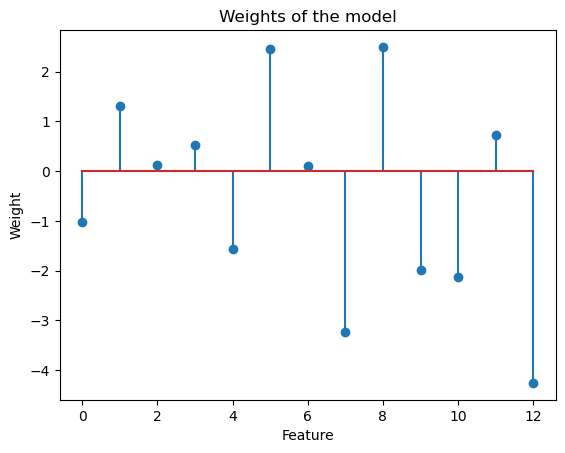

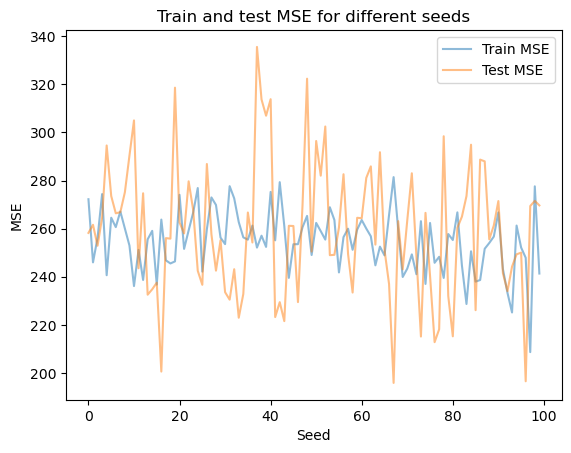

In [103]:
seeds = np.arange(100)
train_mse_history = []
test_mse_history = []
for seed in seeds:
    # Train the least squares regressor
    regressor = least_squares_regressor()

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.3, random_state=seed,shuffle=True)
    
    # convert to numpy arrays
    X_train = X_train.to_numpy()
    X_test = X_test.to_numpy()
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    
    # Scale the data
    X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    
    regressor.fit(X_train, y_train,C=1)

    train_mse = regressor.mse(X_train, y_train)
    train_mse_history.append(train_mse)

    test_mse = regressor.mse(X_test, y_test)
    test_mse_history.append(test_mse)

# Calculate variances
train_mse_variance = np.var(train_mse_history)
test_mse_variance = np.var(test_mse_history)
print("Train MSE variance: ", train_mse_variance)
print("Test MSE variance: ", test_mse_variance)

# Print best MSE for train and test
print("Best train MSE: ", np.min(train_mse_history))
print("Best test MSE: ", np.min(test_mse_history))

# Stem plot of the weights
regressor.plot_weights()

plt.plot(seeds, train_mse_history, label="Train MSE",alpha=0.5)
plt.plot(seeds, test_mse_history, label="Test MSE",alpha=0.5)
plt.xlabel("Seed")
plt.ylabel("MSE")
plt.title("Train and test MSE for different seeds")
plt.legend()
plt.show()



## Performance with Regularization - Show the effect of different levels of regularizations to compute the inverse

Train MSE:  238.3194283782313
Test MSE:  266.56696494297915
Train MSE:  238.31989550547237
Test MSE:  266.56744709342456
Train MSE:  238.3204325819808
Test MSE:  266.56800144267214
Train MSE:  238.3210500811195
Test MSE:  266.5686388008733
Train MSE:  238.32176004405687
Test MSE:  266.56937159639097
Train MSE:  238.3225763143476
Test MSE:  266.570214117919
Train MSE:  238.32351480757364
Test MSE:  266.5711827927876
Train MSE:  238.3245938212777
Test MSE:  266.5722965068551
Train MSE:  238.3258343911932
Test MSE:  266.5735769721817
Train MSE:  238.32726070066613
Test MSE:  266.5750491496013
Train MSE:  238.3289005511824
Test MSE:  266.5767417343588
Train MSE:  238.33078590308943
Test MSE:  266.578687714192
Train MSE:  238.33295349693236
Test MSE:  266.58092501061003
Train MSE:  238.33544556736518
Test MSE:  266.5834972157122
Train MSE:  238.33831066334182
Test MSE:  266.58645443868716
Train MSE:  238.34160459030716
Test MSE:  266.58985427821233
Train MSE:  238.34539149238958
Test MSE:  

Text(0.5, 1.0, 'Train MSE for different regularization terms')

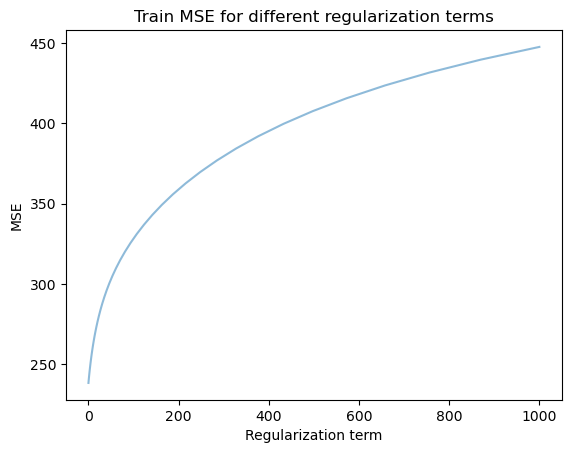

In [104]:
Reg_term = np.logspace(-3, 3, 100)
train_mse_history = []

for reg_term in Reg_term:
    regressor = least_squares_regressor()
    regressor.fit(X_train, y_train, C=reg_term)
    train_mse = regressor.mse(X_train, y_train)
    train_mse_history.append(train_mse)
    
    test_mse = regressor.mse(X_test, y_test)
    test_mse_history.append(test_mse)
    
    print("Train MSE: ", train_mse)
    print("Test MSE: ", test_mse)
    
plt.plot(Reg_term, train_mse_history, label="Train MSE",alpha=0.5)
plt.xlabel("Regularization term")
plt.ylabel("MSE")
plt.title("Train MSE for different regularization terms")

# LMS Algorithm

In [105]:
# Scale the data
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

BEST EPOCH:  99999


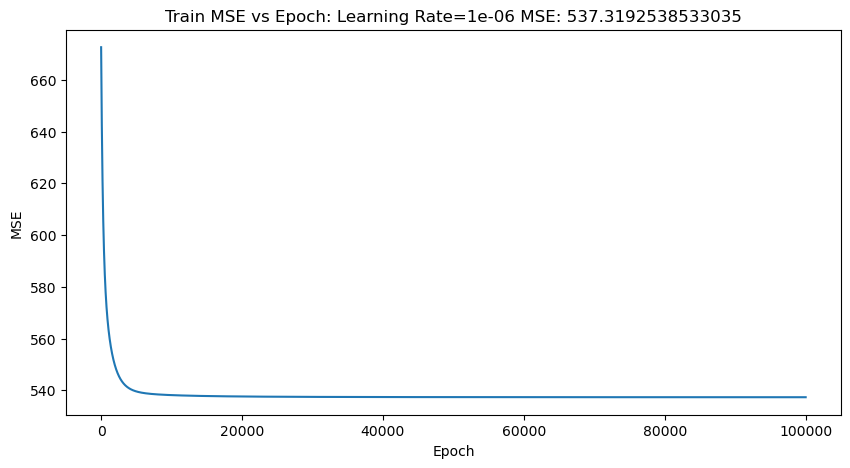

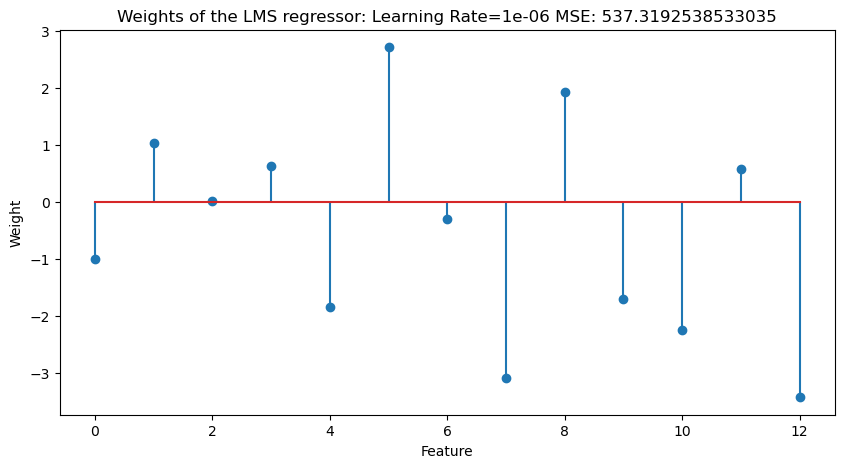

BEST EPOCH:  71498


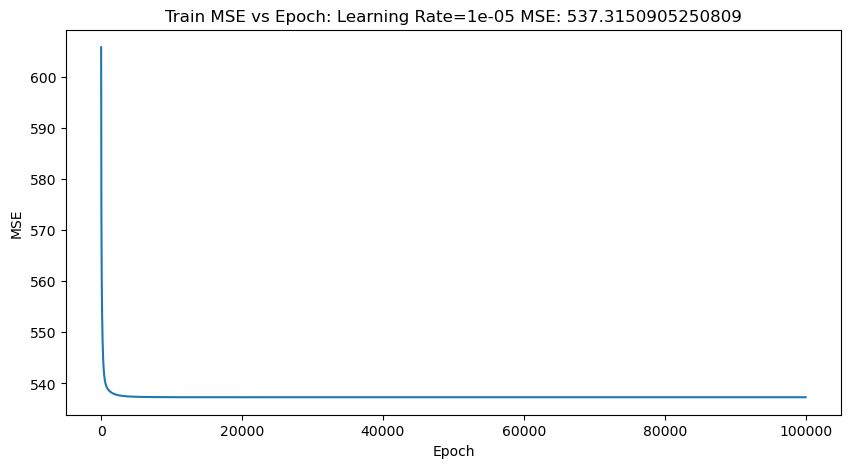

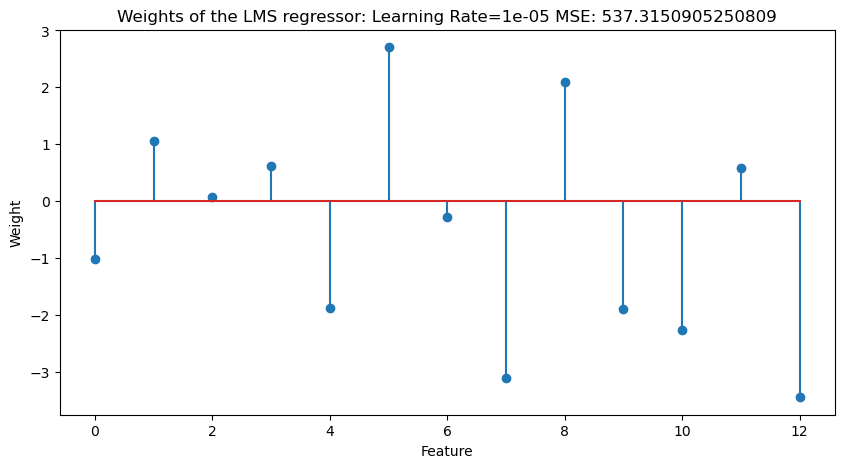

BEST EPOCH:  7115


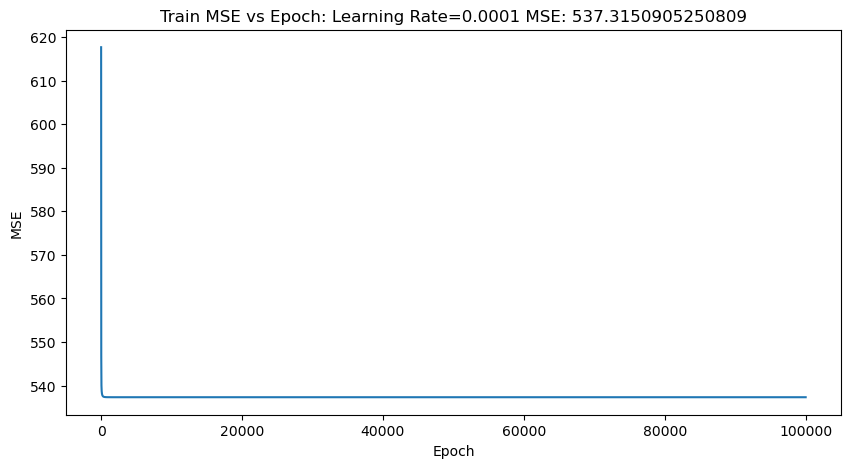

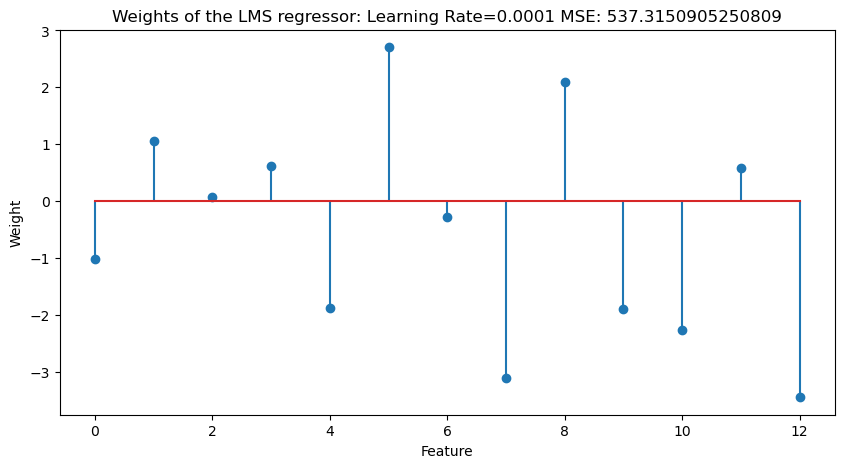

BEST EPOCH:  99999


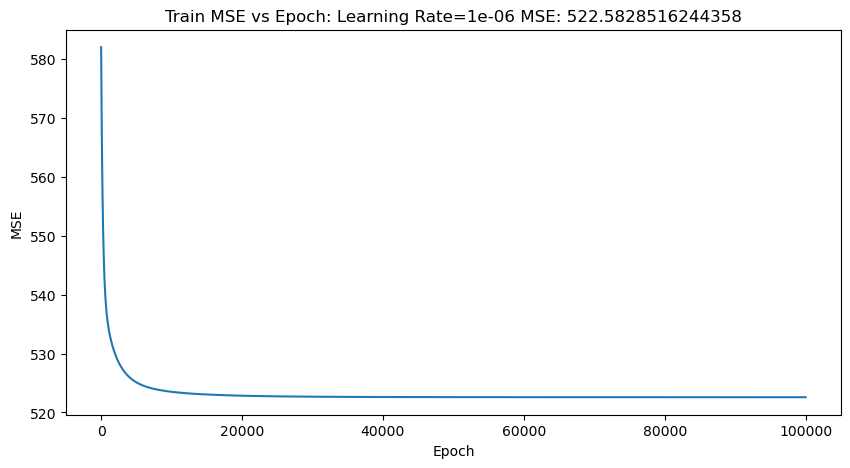

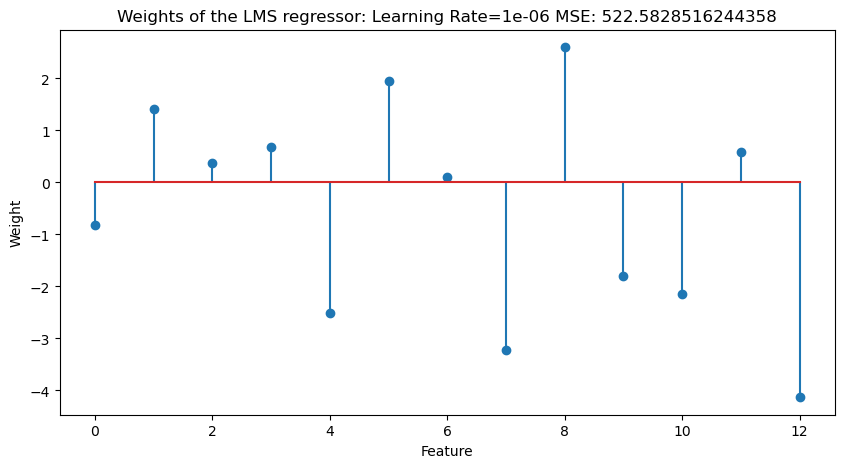

BEST EPOCH:  73151


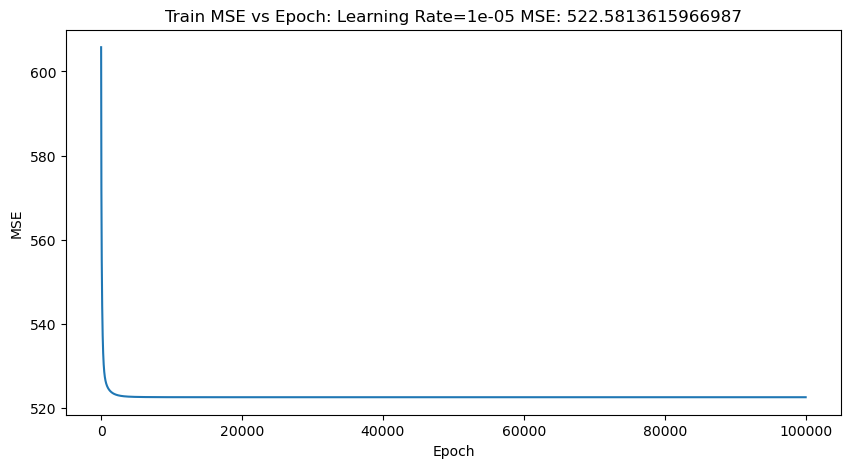

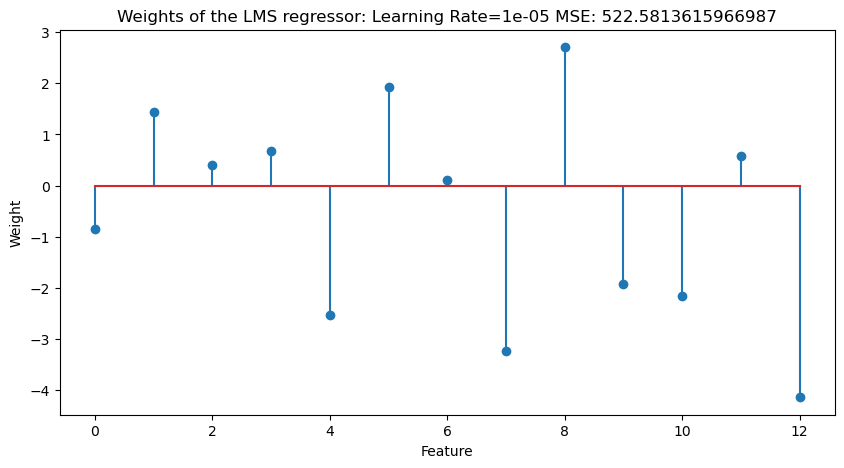

BEST EPOCH:  7540


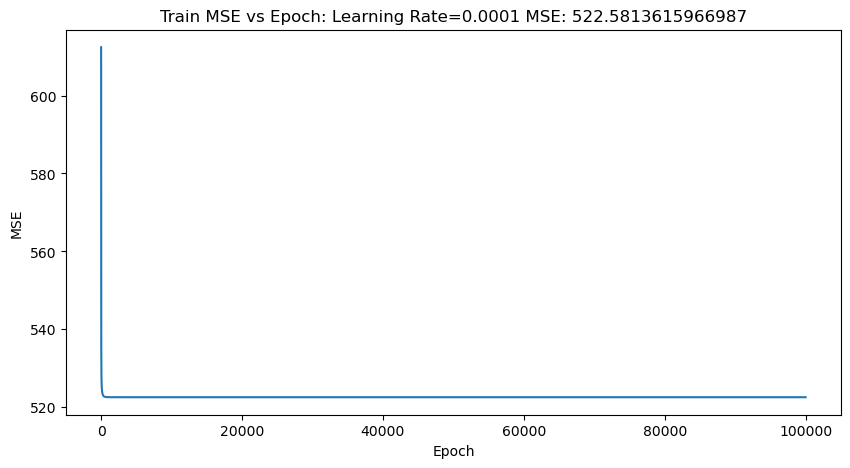

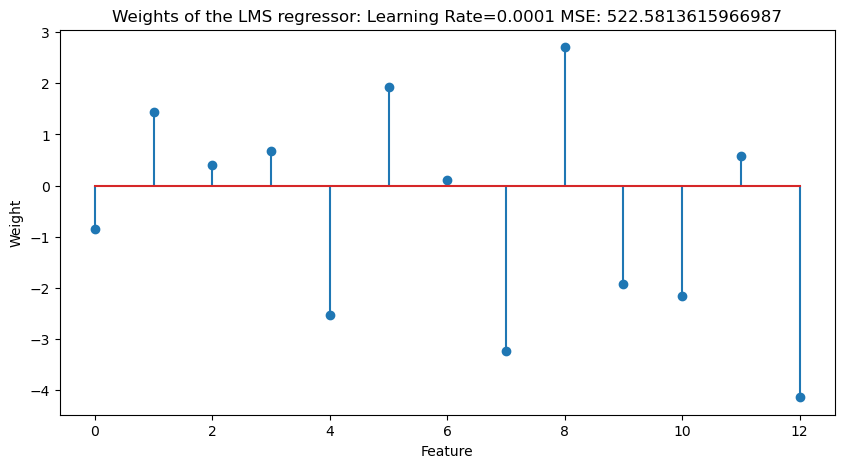

BEST EPOCH:  99999


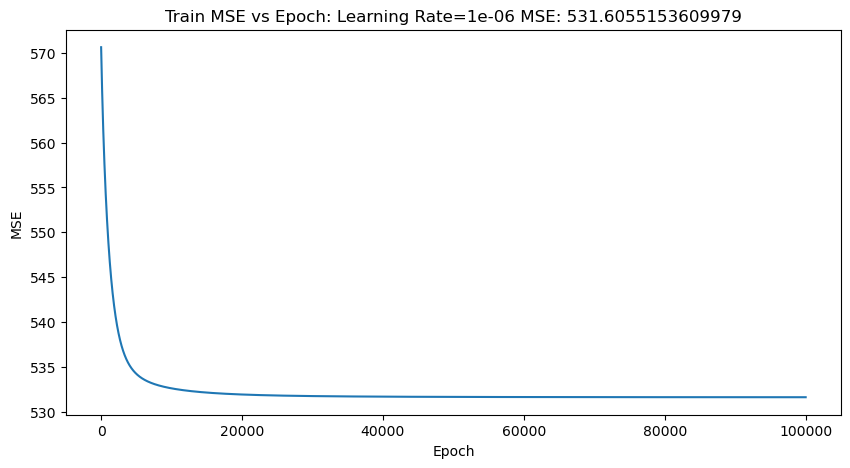

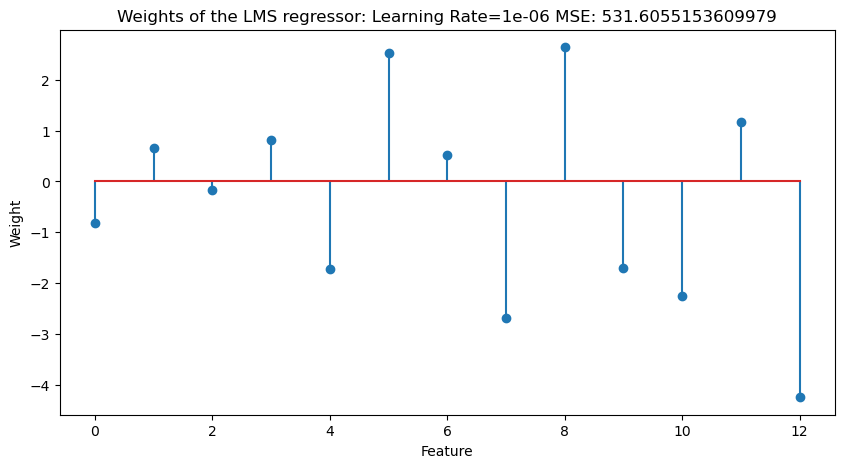

BEST EPOCH:  63288


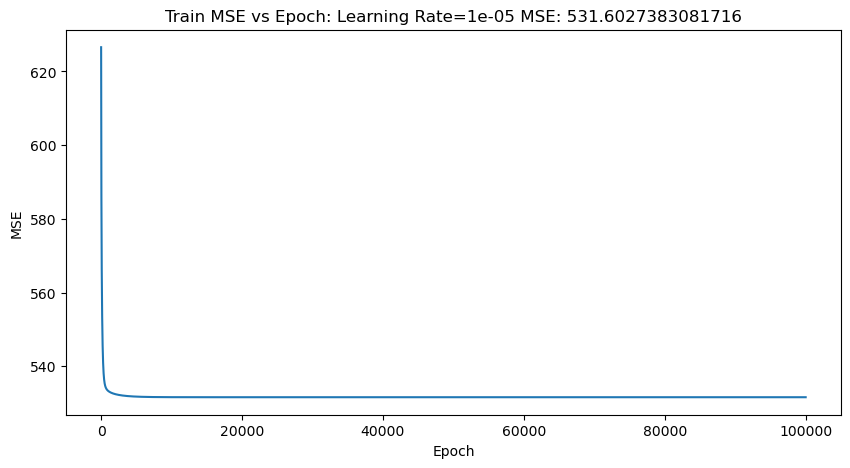

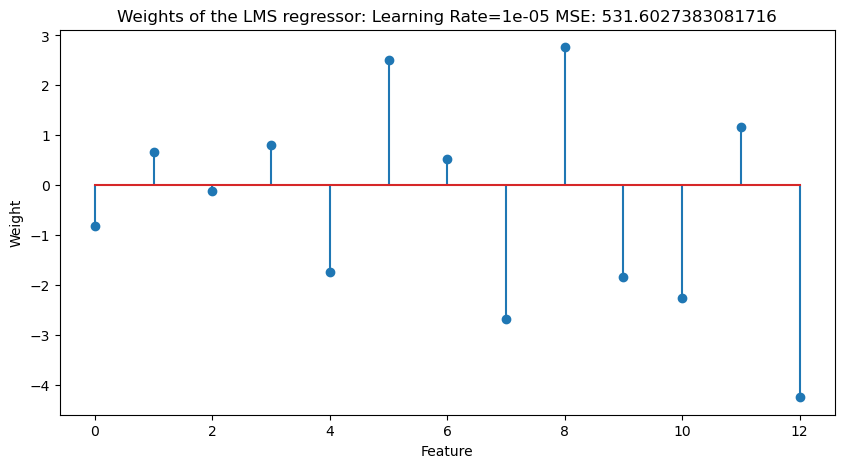

BEST EPOCH:  6163


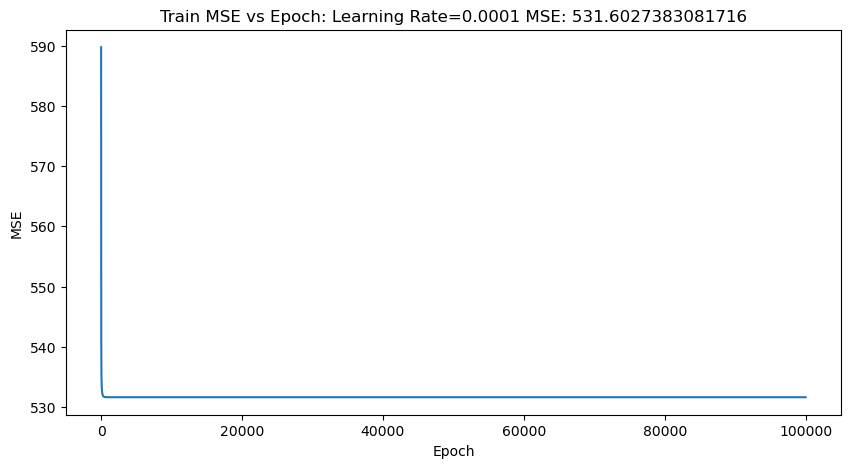

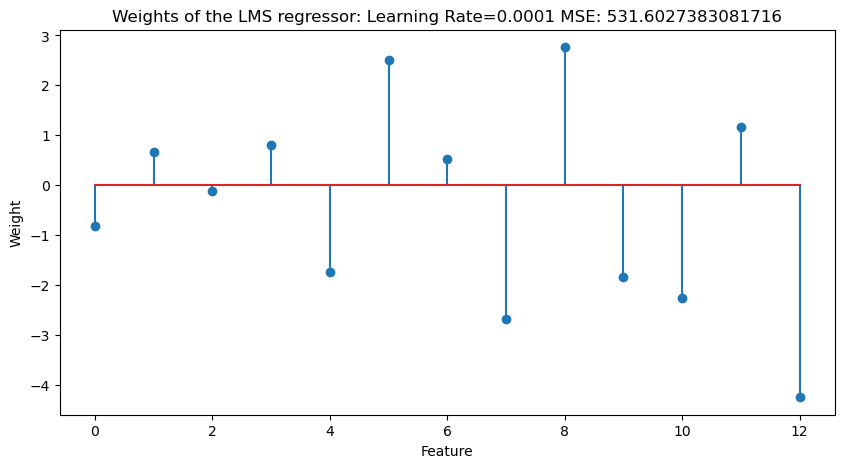

In [106]:
class LMSRegression:
    def __init__(self,learning_rate,epochs):
        # Hyperparameters
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.loss_history=[]
    def fit(self, X,d):
        # Initialize weights and biases
        n_samples, m_weights = X.shape
        self.weights=np.random.randn(m_weights)
        # Training loop - epochs
        for epoch in range(self.epochs):
                
            # Calculate the error
            e = d - X@self.weights
            # Calculate the gradient vector
            grad_vector = self.learning_rate*e@X
            
            # Update the weights
            self.weights = self.weights + grad_vector
            
            # Calculate mse
            mse = self.mse(X,d)
            self.loss_history.append(mse)
                
    def predict(self,X):
        return X @self.weights
    
    def mse(self,X,y):
        return np.mean((self.predict(X)-y)**2)
    
    def get_weights(self):
        return self.weights
    
    def plot_weights(self):
        plt.figure(figsize=(10,5))
        plt.stem(self.weights)
        plt.xlabel("Feature")
        plt.ylabel("Weight")
        plt.title("Weights of the LMS regressor: Learning Rate=" + str(self.learning_rate) + " MSE: " + str(self.get_best_mse()))
        plt.show()
    
    def plot_loss(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.loss_history)
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title("Train MSE vs Epoch: Learning Rate=" + str(self.learning_rate) + " MSE: " + str(self.get_best_mse()))
        plt.show()
        
    def get_best_epoch(self):
        best_epoch = np.argmin(self.loss_history)
        return best_epoch
    
    def get_best_mse(self):
        best_mse = np.min(self.loss_history)
        return best_mse
    
# Test LMS across learning rates
learning_rates=[0.1e-5,0.1e-4,0.1e-3]
seeds = np.arange(3)
best_mses=[]
validation_mses=[]
for seed in seeds:
    for learning_rate in learning_rates:
    
    # Train test split
        X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.3, random_state=seed,shuffle=True)
        
        # convert to numpy arrays
        X_train = X_train.to_numpy()
        X_test = X_test.to_numpy()
        y_train = y_train.to_numpy()
        y_test = y_test.to_numpy()
        
        # Scale the data
        X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
        X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
        
        # Fit LMS
        lms = LMSRegression(learning_rate=learning_rate, epochs=100_000)
        lms.fit(X_train, y_train)
        y_pred = lms.predict(X_test)

        # Print Best Epoch
        print("BEST EPOCH: ", lms.get_best_epoch())

        validation_mses.append(lms.mse(X_test, y_test))
        
        # Plot the loss
        lms.plot_loss() 
        
        # Plot weights
        lms.plot_weights()
        
        # Get best errors
        best_mses.append((str(seed), str(learning_rate), lms.get_best_mse()))


## Calculate the variances across learning rates and seeds

In [107]:
# Calculate the variance across best MSEs
print("Seed" +  " Learning_Rate" + " MSE" + "\n")
#print(np.array(best_mses))

# Calculate training MSE variance
print("Training MSE variance: ", np.var([float(mse[2]) for mse in best_mses]))

# Calculate the variance across best validation MSEs
print("Validation MSE variance: ", np.var(validation_mses))

# Get best MSE in validation set
best_mse = np.min(validation_mses)
print("Best MSE: ", best_mse)


Seed Learning_Rate MSE

Training MSE variance:  36.79314125942462
Validation MSE variance:  199.3511026015759
Best MSE:  513.5320806886574


In [108]:
# Calculate test error with best parameters
lms = LMSRegression(learning_rate=0.1e-3, epochs=100_000)
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.3, random_state=1,shuffle=True)

# numpy conversion
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# Scale Data Again
X_train = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)

lms.fit(X_train, y_train)

print("Test MSE: ", lms.mse(X_test, y_test))
print("Train MSE: ", lms.mse(X_train, y_train))


Test MSE:  547.7890345704169
Train MSE:  522.5813615966987


## Compare LMS w/ LS for best model paramters


From the experiment presented, the best parameters were ```random seed=1``` and ```LR=0.1e-3```. However LMS still converged to a worse solution.

## What happens if target variable is used as input?

The MSE will go to 1.

[[20.4]
 [16. ]
 [13.3]
 [30.8]
 [27.5]
 [24.4]
 [24.4]
 [25.1]
 [43.8]
 [21.9]
 [26.2]
 [14.2]
 [20.8]
 [20.1]
 [23.1]
 [13.1]
 [16.2]
 [24.8]
 [20.2]
 [22.5]
 [14.8]
 [28.7]
 [20.1]
 [23.4]
 [32. ]
 [19.1]
 [50. ]
 [20.9]
 [21.7]
 [22. ]
 [17.2]
 [30.3]
 [12.3]
 [21.4]
 [20.5]
 [35.2]
 [19.6]
 [22. ]
 [21.7]
 [14.1]
 [21.1]
 [15. ]
 [11.9]
 [20. ]
 [41.3]
 [18.7]
 [50. ]
 [50. ]
 [18.4]
 [17.9]
 [28.1]
 [16.1]
 [17.2]
 [28.6]
 [23.6]
 [20.4]
 [19.6]
 [18.8]
 [22.6]
 [17.7]
 [30.5]
 [18.2]
 [20.6]
 [24.4]
 [17.3]
 [13.3]
 [22.8]
 [20.5]
 [21.2]
 [18.8]
 [18.9]
 [18.2]
 [23.1]
 [32.7]
 [24. ]
 [10.2]
 [19.5]
 [33.1]
 [13.4]
 [15.2]
 [24.8]
 [24.3]
 [ 9.5]
 [24.2]
 [18.5]
 [44. ]
 [50. ]
 [24.7]
 [21.5]
 [ 8.4]
 [21.8]
 [50. ]
 [23.8]
 [32.4]
 [24.4]
 [17.6]
 [29.8]
 [ 9.6]
 [16.7]
 [13.8]
 [32. ]
 [16.1]
 [ 8.3]
 [26.6]
 [14.3]
 [15. ]
 [28.4]
 [32.2]
 [17.1]
 [29.4]
 [10.4]
 [16.8]
 [31.5]
 [27.5]
 [46.7]
 [27.5]
 [17.2]
 [23.4]
 [31.6]
 [13.8]
 [22. ]
 [17. ]
 [24.8]
 [24.3]
 [25.2]


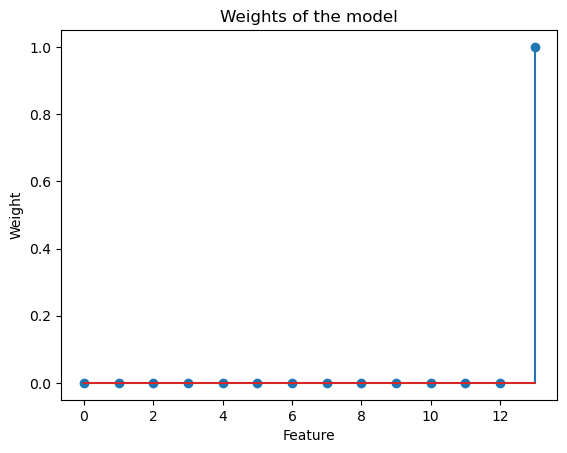

In [109]:
# Construct Algo
least_squares = least_squares_regressor()
# Append y_train to X_train
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
X_test_bad = np.hstack((X_test, y_test))
X_train_bad = np.hstack((X_train, y_train))
print(y_train,'\n')
print(pd.DataFrame(X_train))

# Fit bad data
least_squares.fit(X_train_bad, y_train)
print("Least Squares Test MSE: ", least_squares.mse(X_test_bad, y_test))
print("Least Squares Train MSE: ", least_squares.mse(X_train_bad, y_train))

# Plot weights
least_squares.plot_weights()


# LMS with Bias term

In [110]:
class LMSRegression_w_bias:
    def __init__(self,learning_rate,epochs):
        # Hyperparameters
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.loss_history=[]
    def fit(self, X,d,bias=0):
        # Initialize weights and biases
        n_samples, m_weights = X.shape
        self.weights=np.random.randn(m_weights)
        self.bias=bias
        # Training loop - epochs
        for epoch in range(self.epochs):
                
            # Calculate the error
            e = d - X@self.weights+bias
            # Calculate the gradient vector
            grad_vector = self.learning_rate*e@X
            
            # Update the weights
            self.weights = self.weights + grad_vector
            
            # Calculate mse
            mse = self.mse(X,d)
            self.loss_history.append(mse)
                
    def predict(self,X):
        return X @self.weights +self.bias
    
    def mse(self,X,y):
        return np.mean((self.predict(X)-y)**2)
    
    def get_weights(self):
        return self.weights
    
    def plot_weights(self):
        plt.figure(figsize=(10,5))
        plt.stem(self.weights)
        plt.xlabel("Feature")
        plt.ylabel("Weight")
        plt.title("Weights of the LMS regressor: Learning Rate=" + str(self.learning_rate) + " MSE: " + str(self.get_best_mse()))
        plt.show()


In [111]:
# Fit LMS with bias
lms = LMSRegression_w_bias(learning_rate=0.1e-3, epochs=100_000)
lms.fit(X_train, y_train,bias=1)

print("Test MSE: ", lms.mse(X_test, y_test))
print("Train MSE: ", lms.mse(X_train, y_train))


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 354 is different from 13)

# Exam Review

In [112]:
# Print data shapes
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(354, 13)
(354, 1)
(152, 13)
(152, 1)


(13, 1)
Epoch 1/100, Loss: 662.5101302550684
Epoch 2/100, Loss: 625.836298546957
Epoch 3/100, Loss: 601.3104519814965
Epoch 4/100, Loss: 584.6706006116815
Epoch 5/100, Loss: 573.1702033793349
Epoch 6/100, Loss: 565.0376494091656
Epoch 7/100, Loss: 559.1286622974624
Epoch 8/100, Loss: 554.7027587494856
Epoch 9/100, Loss: 551.2794778608029
Epoch 10/100, Loss: 548.5459058935178
Epoch 11/100, Loss: 546.2971865627698
Epoch 12/100, Loss: 544.3982432055403
Epoch 13/100, Loss: 542.7591421723578
Epoch 14/100, Loss: 541.3192293439905
Epoch 15/100, Loss: 540.0369094525354
Epoch 16/100, Loss: 538.8830552946197
Epoch 17/100, Loss: 537.8367524284976
Epoch 18/100, Loss: 536.8825469517967
Epoch 19/100, Loss: 536.0086610310091
Epoch 20/100, Loss: 535.2058318770205
Epoch 21/100, Loss: 534.4665526931119
Epoch 22/100, Loss: 533.7845731071404
Epoch 23/100, Loss: 533.1545673914742
Epoch 24/100, Loss: 532.5719114377887
Epoch 25/100, Loss: 532.0325304609222
Epoch 26/100, Loss: 531.5327929179122
Epoch 27/100, 

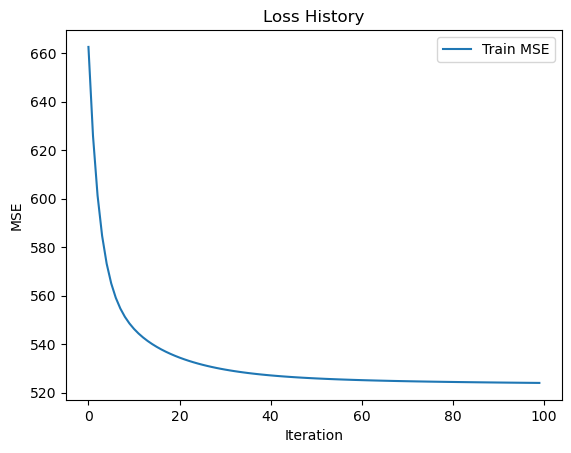

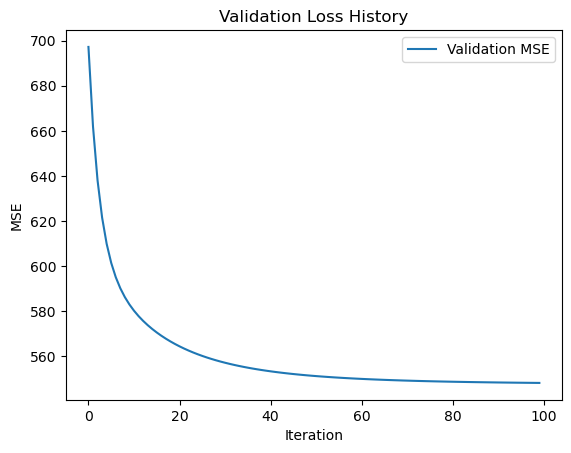

In [128]:
from sklearn.metrics import accuracy_score
# Set random seed
np.random.seed(1)

# Initialize weights
w = np.random.randn(X_train.shape[1], 1)
print(w.shape)

learning_rate = 0.1e-3
loss_history = []
valid_loss_history = []
epochs = 100
n_samples = X_train.shape[0]
valid_lc = []
for epoch in range(epochs):
    for i in range(n_samples):
        # Calculate the error
        e = y_train[i] - np.dot(X_train[i], w).item()
        # Calculate the error without using numpy functions
        e = y_train[i] - sum(X_train[i][j] * w[j] for j in range(len(w)))
        
        # Define the inst gradient vector
        grad = learning_rate * e * X_train[i].reshape(-1, 1)
        
        # Update the weights
        w += grad
        
    # Make prediction
    y_pred = X_test @ w
    
    # Calculate test accuracies
    loss = np.mean((y_pred - y_test)**2)
    valid_loss_history.append(loss)
    
    # Calculate train accuracies
    loss = np.mean((X_train @ w - y_train)**2)
    loss_history.append(loss)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss}")

# Plot the loss history
plt.plot(loss_history, label="Train MSE")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss History")
plt.legend()
plt.show()

# Plot the validation loss history
plt.plot(valid_loss_history, label="Validation MSE")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Validation Loss History")
plt.legend()
plt.show()



In [ ]:
X_train[1].shape

(13,)